# Assignment 2. Option 2

## Dataset Exploration

In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
!bash ./src/download_voxconverse.sh

Annotations already present, skipping clone.
Audio already present, skipping download.


## Pyannote-Based System

## Custom Implementation (PyTorch / Torchaudio / PyTorch-Lightning)

In [5]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("data")
AUDIO_DIR = DATA_DIR / "audio"
ANNOTATIONS_DIR = DATA_DIR / "annotations"
DIR_DEV = "dev"
DIR_TEST = "test"
SAMPLE_RATE = 16_000
HOP = 200

In [6]:
from src.dataset import VoxConverseDataset, make_collate_fn
from torch.utils.data import DataLoader

dataset_dev = VoxConverseDataset(
  annotations_dir=ANNOTATIONS_DIR / DIR_DEV,
  audio_dir=AUDIO_DIR / DIR_DEV,
  sample_rate=SAMPLE_RATE,
)

dataset_test = VoxConverseDataset(
  annotations_dir=ANNOTATIONS_DIR / DIR_TEST,
  audio_dir=AUDIO_DIR / DIR_TEST,
  sample_rate=SAMPLE_RATE,
)

dataloader_dev = DataLoader(
  dataset_dev,
  shuffle=True,
  collate_fn=make_collate_fn(HOP, SAMPLE_RATE),
)

dataloader_test = DataLoader(
  dataset_test,
  shuffle=True,
)

In [24]:
import librosa

pd.Series(
    [librosa.get_samplerate(f) for f in dataset_dev.audio_files + dataset_test.audio_files]
).value_counts()

16000    448
Name: count, dtype: int64

In [ ]:
from src.dataset import RTTM_COLUMNS

dev_path = ANNOTATIONS_DIR / DIR_DEV
test_path = ANNOTATIONS_DIR / DIR_TEST

def prep_data(path):
    return pd.concat(
        [pd.read_csv(f, sep=r"\s+", header=None, names=RTTM_COLUMNS) for f in path.iterdir()],
        ignore_index=True,
    )

dataset_dev.annotations

df_dev = prep_data(dev_path)
df_test = prep_data(test_path)


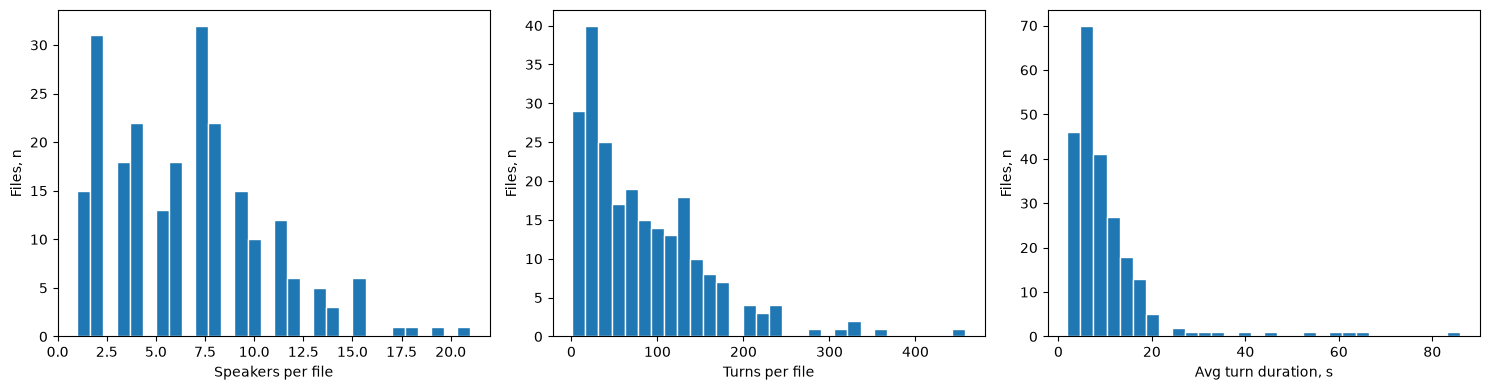

In [ ]:
import matplotlib.pyplot as plt

stats = df_test.groupby("file_id").agg(
    n_speakers=("speaker", "nunique"),
    n_turns=("speaker", "count"),
    avg_turn_dur=("duration", "mean"),
)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, col, xlabel in zip(
    axes,
    ["n_speakers", "n_turns", "avg_turn_dur"],
    ["Speakers per file", "Turns per file", "Avg turn duration, s"],
):
    ax.hist(stats[col], bins=30, edgecolor="white")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Files, n")
    ax.grid(False)

plt.tight_layout()
plt.show()



In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TDNN(nn.Module):
    def __init__(self, in_dim, out_dim, k, d=1):
        super().__init__()
        self.conv = nn.Conv1d(in_dim, out_dim, kernel_size=k, dilation=d)
        self.bn = nn.BatchNorm1d(out_dim)

    def forward(self, x):
        return torch.relu(self.bn(self.conv(x)))


class StatsPool(nn.Module):
    def forward(self, x):
        mean = x.mean(dim=-1)
        std = x.std(dim=-1)
        return torch.cat([mean, std], dim=-1)


class XVector(nn.Module):
    def __init__(self, n_mels=40, emb_dim=512, n_speakers=100):
        super().__init__()
        self.frame = nn.Sequential(
            TDNN(n_mels, 512, k=5, d=1),
            TDNN(512, 512, k=3, d=2),
            TDNN(512, 512, k=3, d=3),
            TDNN(512, 512, k=1, d=1),
            TDNN(512, 1500, k=1, d=1),
        )
        self.pool = StatsPool()
        self.seg1 = nn.Linear(3000, emb_dim)
        self.seg_bn = nn.BatchNorm1d(emb_dim)
        self.seg2 = nn.Linear(emb_dim, emb_dim)
        self.head = nn.Linear(emb_dim, n_speakers)

    def forward(self, feats, return_embedding=False):
        h = self.frame(feats)
        h = self.pool(h)
        emb = self.seg1(h)
        if return_embedding:
            return F.normalize(emb, dim=1)
        h = self.seg2(torch.relu(self.seg_bn(torch.relu(emb))))
        return self.head(h) 

tensor([[-0.1824, -0.2740,  0.1716, -0.1166,  1.1178,  1.3647,  1.3308,  0.6645],
        [ 0.0836,  0.2683,  0.0344, -0.3167,  0.9947,  0.9212,  0.8935,  1.3498]])
True
True
